Expérience 1 Labo III
Lucile Le Liboux

Analyse des séries temporelles

In [1]:
# importation des librairies
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import cartopy.crs as ccrs

In [2]:
# Ouvrir le fichier
ds = ds = xr.open_dataset("C:/Users/lucil/OneDrive/Documents/Automne 2026/SCA5460 - Laboratoire III/Experience1/imerg_pr_201911_3h.nc4")

In [3]:
# Afficher un résumé du contenu (dimensions, coordonnées, variables, attributs)
ds


<xarray.Dataset> Size: 6GB
Dimensions:           (time: 240, bnds: 2, lat: 1800, lon: 3600)
Coordinates:
  * time              (time) datetime64[ns] 2kB 2019-11-01 ... 2019-11-30T21:...
  * lat               (lat) float32 7kB -89.95 -89.85 -89.75 ... 89.85 89.95
  * lon               (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.9 179.9
Dimensions without coordinates: bnds
Data variables:
    time_bnds         (time, bnds) datetime64[ns] 4kB ...
    precipitationCal  (time, lat, lon) float32 6GB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.5 (http://mpimet.mpg.de/...
    history:      Mon Sep 27 17:58:00 2021: cdo --timestat_date first -L -f n...
    Conventions:  CF-1.6
    FileHeader:   DOI=10.5067/GPM/IMERG/3B-HH/06;\nDOIauthority=http://dx.doi...
    FileInfo:     DataFormatVersion=6a;\nTKCodeBuildVersion=0;\nMetadataVersi...
    GridHeader:   BinMethod=ARITHMETIC_MEAN;\nRegistration=CENTER;\nLatitudeR...
    CDO:          Climate Data Operators version 1.9.5 (http://mpimet.mpg.de/...

In [4]:
da = ds ["precipitationCal"]
da

<xarray.DataArray 'precipitationCal' (time: 240, lat: 1800, lon: 3600)> Size: 6GB
[1555200000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2019-11-01 ... 2019-11-30T21:00:00
  * lat      (lat) float32 7kB -89.95 -89.85 -89.75 -89.65 ... 89.75 89.85 89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 179.9
Attributes:
    units:    mm/3h

In [5]:
#1 et 2)coordonnées des 4 points étudiés - points de grille les plus proches
#Série temporelle Jakarta, la méthode nearest permet d'attraper le point de grille le plus proche de ses coordonnées

serietempjak = ds["precipitationCal"].sel(lat=6.2, lon=106.8, method="nearest")

#Série temporelle Québec
serietempqc = ds["precipitationCal"].sel(lat=46.8, lon=-71.2, method="nearest")

#Série temporelle océan
serietempoc = ds["precipitationCal"].sel(lat=-7, lon=106, method="nearest")

#Série temporelle Bologne
serietempbo = ds["precipitationCal"].sel(lat=44.48, lon=11.33, method="nearest")

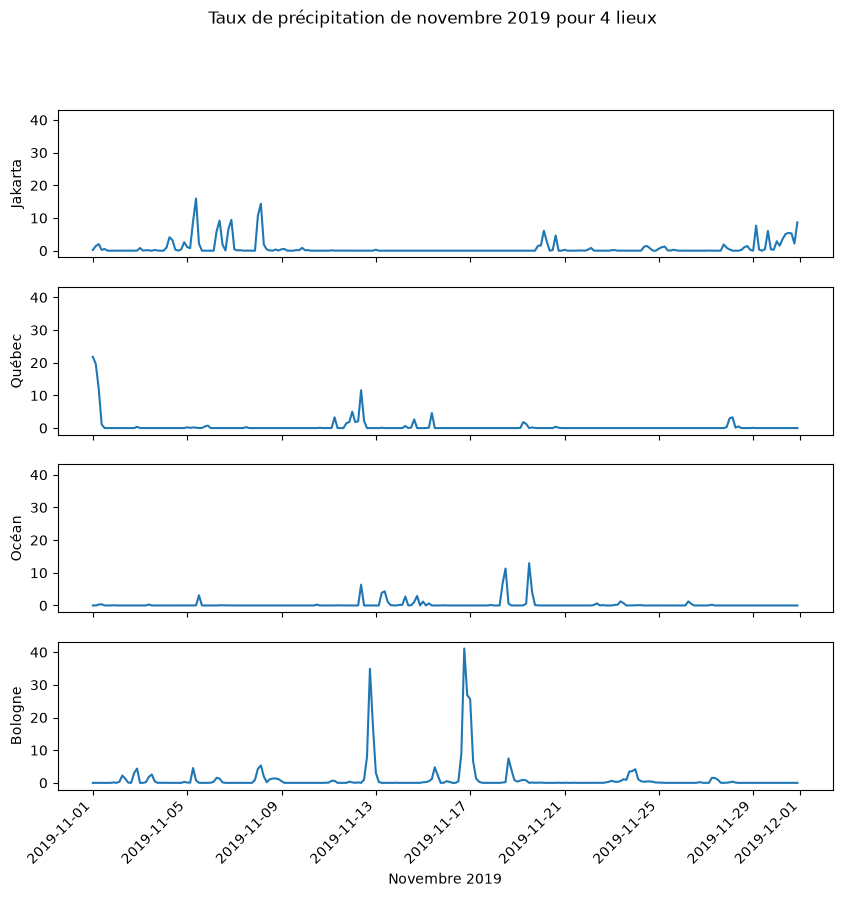

In [6]:
#2)tracer les 4 panneaux graphiques 

#sharey permet de conserver la même plage de valeur pour les 4 axes y, pareil pour sharex et l'axe x
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, sharex=True, sharey=True, figsize=(10,10))
fig.suptitle("Taux de précipitation de novembre 2019 pour 4 lieux")


ax1.plot(serietempjak["time"], serietempjak)
ax1.set_ylabel("Jakarta")

ax2.plot(serietempqc["time"],serietempqc)
ax2.set_ylabel("Québec")

ax3.plot(serietempoc["time"],serietempoc)
ax3.set_ylabel("Océan")

ax4.plot(serietempbo["time"],serietempbo)
ax4.set_ylabel("Bologne")
ax4.set_xlabel("Novembre 2019")

#inclinaison des dates sur l'axe x
fig.autofmt_xdate(rotation=45)

plt.savefig("QuestionA2.png", bbox_inches="tight")

plt.show()

In [7]:
#3a)accumulation totale des précipitations
#on calcule la somme à un point donné
#Jakarta 
jakarta = da.sel(lat=-6.2, lon=106.8, method="nearest")
accum_jakarta = jakarta.sum(dim="time")
print("Accumulation à Jakarta en novembre 2019 :", f"{accum_jakarta:.2f}", "mm")

#Québec 
quebec = da.sel(lat=46.8, lon=-71.2, method="nearest")
accum_quebec = quebec.sum(dim="time")
print("Accumulation à Québec en novembre 2019 :", f"{accum_quebec:.2f}", "mm")

#point à Bologne Pacifique
ocean = da.sel(lat=7, lon=106, method="nearest")
accum_ocean = ocean.sum(dim="time")
print("Accumulation dans un point de l'océan Pacifique en novembre 2019 :", f"{accum_ocean:.2f}", "mm")

#Bologne
bologne = da.sel(lat=44.5, lon=11.3, method="nearest")
accum_bologne = bologne.sum(dim="time")
print("Accumulation à Bologne en novembre 2019 :", f"{accum_bologne:.2f}", "mm")

Accumulation à Jakarta en novembre 2019 : 173.99 mm
Accumulation à Québec en novembre 2019 : 106.28 mm
Accumulation dans un point de l'océan Pacifique en novembre 2019 : 123.81 mm
Accumulation à Bologne en novembre 2019 : 286.46 mm


In [8]:
#b)nombre de mesures avec un taux de précipitations supérieures à 0 mm/3h
#la fonction somme toutes les precipitationsCal supérieures à 0 sur la période de novembre 2019
#Jakarta
nombre_mesures_jakarta = (jakarta > 0).sum(dim="time")
print("nombre de mesures supérieures à 0 mm/3h à Jakarta :",int(nombre_mesures_jakarta))

#Québec
nombre_mesures_quebec = (quebec > 0).sum(dim="time")
print("nombre de mesures supérieures à 0 mm/3h à Québec :",int(nombre_mesures_quebec))

#Océan
nombre_mesures_ocean = (ocean > 0).sum(dim="time")
print("nombre de mesures supérieures à 0 mm/3h dans le Pacifique :",int(nombre_mesures_ocean))

#Bologne
nombre_mesures_bologne = (bologne > 0).sum(dim="time")
print("nombre de mesures supérieures à 0 mm/3h à Bologne :",int(nombre_mesures_bologne))

nombre de mesures supérieures à 0 mm/3h à Jakarta : 100
nombre de mesures supérieures à 0 mm/3h à Québec : 61
nombre de mesures supérieures à 0 mm/3h dans le Pacifique : 96
nombre de mesures supérieures à 0 mm/3h à Bologne : 152


In [9]:
#Fraction du temps où il pleut : fréquence de précipitation
#il y a 240 mesures de temps dans le xarray. Ainsi, la fréquance est le nombre de fois  > 0 divisé par 240

#Assurons nous que le nombre de mesures est bien 240.
nombre_total = jakarta.sizes["time"]
print("nombre de mesures totales :", nombre_total)

nombre de mesures totales : 240


In [10]:
#b)On peut ainsi procéder au calcul de la fréquence

#fréquence à Jakarta 
freq_jakarta = nombre_mesures_jakarta*100 / nombre_total
print("Fréquence de pluie à Jakarta :", f"{freq_jakarta:.2f}", "% du temps en novembre 2019")


#fréquence à Québec
freq_quebec = nombre_mesures_quebec*100 / nombre_total
print("Fréquence de pluie à Québec :", f"{freq_quebec:.2f}", "% du temps en novembre 2019")

#fréquence dans le point du Pacifique
freq_ocean = nombre_mesures_ocean*100 / nombre_total
print("Fréquence de pluie dans le Pacifique:", f"{freq_ocean:.2f}", "% du temps en novembre 2019")

#fréquence à Bologne 
freq_bologne = nombre_mesures_bologne*100 / nombre_total
print("Fréquence de pluie à Bologne :", f"{freq_bologne:.2f}", "% du temps en novembre 2019")

Fréquence de pluie à Jakarta : 41.67 % du temps en novembre 2019
Fréquence de pluie à Québec : 25.42 % du temps en novembre 2019
Fréquence de pluie dans le Pacifique: 40.00 % du temps en novembre 2019
Fréquence de pluie à Bologne : 63.33 % du temps en novembre 2019


In [11]:
#c1)précipitations moyennes
#moyenne toutes les précip
#Jakarta
moyenne_precip_jakarta = accum_jakarta/nombre_total
print ("Les précipitations moyennes à Jakarta sont de", f"{moyenne_precip_jakarta:.2f}", "mm/3h")

#Québec
moyenne_precip_quebec = accum_quebec/nombre_total
print ("Les précipitations moyennes à Québec sont de", f"{moyenne_precip_quebec:.2f}", "mm/3h")

#océan
moyenne_precip_ocean = accum_ocean/nombre_total
print ("Les précipitations moyennes à Bologne Pacifique sont de", f"{moyenne_precip_ocean:.2f}", "mm/3h")

#Bologne
moyenne_precip_bologne = accum_bologne/nombre_total
print ("Les précipitations moyennes à Bologne sont de", f"{moyenne_precip_bologne:.2f}", "mm/3h")


Les précipitations moyennes à Jakarta sont de 0.72 mm/3h
Les précipitations moyennes à Québec sont de 0.44 mm/3h
Les précipitations moyennes à Bologne Pacifique sont de 0.52 mm/3h
Les précipitations moyennes à Bologne sont de 1.19 mm/3h


In [31]:
#c) intensité des précipitations moyennes : 
intensite_jakarta = moyenne_precip_jakarta/freq_jakarta*100
print("L'intensité des précipitations à Jakarta est de ", f"{intensite_jakarta2:.2f}", "mm/3h")

intensite_quebec = moyenne_precip_quebec/freq_quebec*100
print("L'intensité des précipitations à Québec est de ", f"{intensite_quebec:.2f}", "mm/3h")

intensite_ocean = moyenne_precip_ocean/freq_ocean*100
print("L'intensité des précipitations dans le Pacifique est de ", f"{intensite_ocean:.2f}", "mm/3h")

intensite_bologne = moyenne_precip_bologne/freq_bologne*100
print("L'intensité des précipitations à Bologne est de ", f"{intensite_bologne:.2f}", "mm/3h")

L'intensité des précipitations à Jakarta est de  1.74 mm/3h
L'intensité des précipitations à Québec est de  1.74 mm/3h
L'intensité des précipitations dans le Pacifique est de  1.29 mm/3h
L'intensité des précipitations à Bologne est de  1.88 mm/3h


In [13]:
#d)Evenement de précipitations = regroupement de plusieurs périodes de 3h consécutives
#Jakarta

pluie_jak = jakarta.values > 0

#initialisation des valeurs 
max_consecutif_jak = 0
compteur_jak = 0

#tant que la pluie est supérieure à 0, le compteur de période ajoute 1 (une période)
for val in pluie_jak :
    if val: # si la valeur existe (est supérieure à 0)
        compteur_jak += 1
        max_consecutif_jak = max(max_consecutif_jak, compteur_jak) 
    else: 
        compteur_jak = 0 #remise à 0 quand une période sans pluie interrompt le compteur

#le max consecutif est multiplié par 3 pour les 3heures de la période
print("Nombre d'heures max consécutives avec pluie à Jakarta :", max_consecutif_jak*3, "h")

Nombre d'heures max consécutives avec pluie à Jakarta : 36 h


In [14]:
#Québec

pluie_qc = quebec.values > 0

#initialisation des valeurs 
max_consecutif_qc = 0
compteur_qc = 0

#tant que la pluie est supérieure à 0, le compteur de période ajoute 1 (une période)
for val in pluie_qc :
    if val: # si la valeur existe (est supérieure à 0)
        compteur_qc += 1
        max_consecutif_qc = max(max_consecutif_qc, compteur_qc) 
    else: 
        compteur_qc = 0 #remise à 0 quand une période sans pluie interrompt le compteur

#le max consecutif est multiplié par 3 pour les 3heures de la période
print("Nombre d'heures consécutives max avec pluie à Québec:", max_consecutif_qc*3, "h")

Nombre d'heures consécutives max avec pluie à Québec: 27 h


In [15]:
#Océan

pluie_oc = ocean.values > 0

#initialisation des valeurs 
max_consecutif_oc = 0
compteur_oc = 0

#tant que la pluie est supérieure à 0, le compteur de période ajoute 1 (une période)
for val in pluie_oc :
    if val: # si la valeur existe (est supérieure à 0)
        compteur_oc += 1
        max_consecutif_oc = max(max_consecutif_oc, compteur_oc) 
    else: 
        compteur_oc = 0 #remise à 0 quand une période sans pluie interrompt le compteur

#le max consecutif est multiplié par 3 pour les 3heures de la période
print("Nombre d'heures consécutives max avec pluie dans l'océan:", max_consecutif_oc*3, "h")

Nombre d'heures consécutives max avec pluie dans l'océan: 36 h


In [16]:
#Bologne

pluie_bo = bologne.values > 0

#initialisation des valeurs 
max_consecutif_bo = 0
compteur_bo = 0

#tant que la pluie est supérieure à 0, le compteur de période ajoute 1 (une période)
for val in pluie_bo :
    if val: # si la valeur existe (est supérieure à 0)
        compteur_bo += 1
        max_consecutif_bo = max(max_consecutif_bo, compteur_bo) 
    else: 
        compteur_bo = 0 #remise à 0 quand une période sans pluie interrompt le compteur

#le max consecutif est multiplié par 3 pour les 3heures de la période
print("Nombre d'heures consécutives max avec pluie à Bologne:", max_consecutif_bo*3, "h")

Nombre d'heures consécutives max avec pluie à Bologne: 69 h


In [17]:
#e) valeur maximale du taux de precip
#Jakarta
max_jakarta = jakarta.max(dim="time")
print("La valeur maximale du taux de précipitations à Jakarta est de",f"{max_jakarta:.2f}", "mm/3h")

#Québec
max_quebec = quebec.max(dim="time")
print("La valeur maximale du taux de précipitations à Québec est de",f"{max_quebec:.2f}", "mm/3h")

#Océan
max_ocean = ocean.max(dim="time")
print("La valeur maximale du taux de précipitations dans l'océan Pacifique est de",f"{max_ocean:.2f}", "mm/3h")

#Bologne
max_bologne = bologne.max(dim="time")
print("La valeur maximale du taux de précipitations à Bologne est de",f"{max_bologne:.2f}", "mm/3h")

La valeur maximale du taux de précipitations à Jakarta est de 30.70 mm/3h
La valeur maximale du taux de précipitations à Québec est de 21.81 mm/3h
La valeur maximale du taux de précipitations dans l'océan Pacifique est de 13.36 mm/3h
La valeur maximale du taux de précipitations à Bologne est de 38.70 mm/3h


In [18]:
#f) Création de 4 points de grille à 50 km de chaque emplacement 

import math

#JAKARTA
#on convertit la longitude d'une différence de 50km à l'est et à l'ouest (à la latitude de Jakarta, cos(lat))

lat_jak = -6.2
lon_jak = 106.8

#111km correspond à 1°, on convertit 50km en degré à la latitude donnée
lon_jak_est = lon_jak + 50/(111*math.cos(6.2))
lon_jak_ouest = lon_jak - 50/(111*math.cos(6.2))

#puis la différence nord et sud pour les latitudes

lat_jak_sud = lat_jak - 50/111
lat_jak_nord = lat_jak + 50/111

print("Jakarta Est :", lat_jak, f"{lon_jak_est:.1f}")
print("Jakarta Ouest :", lat_jak, f"{lon_jak_ouest:.1f}")
print("Jakarta Nord :", f"{lat_jak_nord:.1f}", lon_jak)
print("Jakarta Sud :", f"{lat_jak_sud:.1f}", lon_jak)

# Création des 4 points de grille 50 km autour de Jakarta

jak_est = ds.precipitationCal.sel(lat=lat_jak, lon=lon_jak_est, method="nearest")

jak_ouest = ds.precipitationCal.sel(lat=lat_jak, lon=lon_jak_ouest, method="nearest")

jak_nord = ds.precipitationCal.sel(lat=lat_jak_nord, lon=lon_jak, method="nearest")

jak_sud = ds.precipitationCal.sel(lat=lat_jak_sud, lon=lon_jak, method="nearest")

Jakarta Est : -6.2 107.3
Jakarta Ouest : -6.2 106.3
Jakarta Nord : -5.7 106.8
Jakarta Sud : -6.7 106.8


In [19]:
#QUÉBEC
#on convertit la longitude d'une différence de 50km à l'est et à l'ouest (à la latitude de Québec, cos(lat))

lat_qc = 46.8
lon_qc = -71.2

lon_qc_est = lon_qc + 50/(111*math.cos(46.8))
lon_qc_ouest = lon_qc - 50/(111*math.cos(46.8))

#puis la différence nord et sud pour les latitudes

lat_qc_sud = lat_qc - 50/111
lat_qc_nord = lat_qc + 50/111

print("Québec Est :", lat_qc, f"{lon_qc_est:.1f}")
print("Québec Ouest :", lat_qc, f"{lon_qc_ouest:.1f}")
print("Québec Nord :", f"{lat_qc_nord:.1f}", lon_qc)
print("Québec Sud :", f"{lat_qc_sud:.1f}", lon_qc)

# Création des 4 points de grille 50 kmautour de Québec


qc_est = ds.precipitationCal.sel(lat=lat_qc, lon=lon_qc_est, method="nearest")

qc_ouest = ds.precipitationCal.sel(lat=lat_qc, lon=lon_qc_ouest, method="nearest")

qc_nord = ds.precipitationCal.sel(lat=lat_qc_nord, lon=lon_qc, method="nearest")

qc_sud = ds.precipitationCal.sel(lat=lat_qc_sud, lon=lon_qc, method="nearest")

Québec Est : 46.8 -71.7
Québec Ouest : 46.8 -70.7
Québec Nord : 47.3 -71.2
Québec Sud : 46.3 -71.2


In [20]:
#PACIFIQUE
#on convertit la longitude d'une différence de 50km à l'est et à l'ouest (à la latitude du Pacifique, cos(lat))

lat_oc = 7.0
lon_oc = 106.0

lon_oc_est = lon_oc + 50/(111*math.cos(7))
lon_oc_ouest = lon_oc - 50/(111*math.cos(7))

#puis la différence nord et sud pour les latitudes

lat_oc_sud = lat_oc - 50/111
lat_oc_nord = lat_oc + 50/111

print("Pacifique Est :", lat_oc, f"{lon_oc_est:.1f}")
print("Pacifique Ouest :", lat_oc, f"{lon_oc_ouest:.1f}")
print("Pacifique Nord :", f"{lat_oc_nord:.1f}", lon_oc)
print("Pacifique Sud :", f"{lat_oc_sud:.1f}", lon_oc)

# Création des 4 points de grille 50 kmautour du point pacifique


oc_est = ds.precipitationCal.sel(lat=lat_oc, lon=lon_oc_est, method="nearest")

oc_ouest = ds.precipitationCal.sel(lat=lat_oc, lon=lon_oc_ouest, method="nearest")

oc_nord = ds.precipitationCal.sel(lat=lat_oc_nord, lon=lon_oc, method="nearest")

oc_sud = ds.precipitationCal.sel(lat=lat_oc_sud, lon=lon_oc, method="nearest")

Pacifique Est : 7.0 106.6
Pacifique Ouest : 7.0 105.4
Pacifique Nord : 7.5 106.0
Pacifique Sud : 6.5 106.0


In [21]:
#BOLOGNE
#on convertit la longitude d'une différence de 50km à l'est et à l'ouest (à la latitude de Bologne, cos(lat))

lat_bo = 44.5
lon_bo = 11.3

lon_bo_est = lon_bo + 50/(111*math.cos(44.5))
lon_bo_ouest = lon_bo - 50/(111*math.cos(44.5))

#puis la différence nord et sud pour les latitudes

lat_bo_sud = lat_bo - 50/111
lat_bo_nord = lat_bo + 50/111

print("Bologne Est :", lat_bo, f"{lon_bo_est:.1f}")
print("Bologne Ouest :", lat_bo, f"{lon_bo_ouest:.1f}")
print("Bologne Nord :", f"{lat_bo_nord:.1f}", lon_bo)
print("Bologne Sud :", f"{lat_bo_sud:.1f}", lon_bo)

# Création des 4 points de grille 50 kmautour de bologne

bo_est = ds.precipitationCal.sel(lat=lat_bo, lon=lon_bo_est, method="nearest")

bo_ouest = ds.precipitationCal.sel(lat=lat_bo, lon=lon_bo_ouest, method="nearest")

bo_nord = ds.precipitationCal.sel(lat=lat_bo_nord, lon=lon_bo, method="nearest")

bo_sud = ds.precipitationCal.sel(lat=lat_bo_sud, lon=lon_bo, method="nearest")


Bologne Est : 44.5 11.8
Bologne Ouest : 44.5 10.8
Bologne Nord : 45.0 11.3
Bologne Sud : 44.0 11.3


In [22]:
# coefficient de Pearson, avec aide de l'IA pour comprendre le fonctionnement de corrcoef

#Jakarta

# coefficient de Pearson

corr_estjak = np.corrcoef(jakarta.values, jak_est.values)[0, 1]
corr_ouestjak = np.corrcoef(jakarta.values, jak_ouest.values)[0, 1]
corr_nordjak = np.corrcoef(jakarta.values, jak_nord.values)[0, 1]
corr_sudjak = np.corrcoef(jakarta.values, jak_sud.values)[0, 1]

print("corrélation temporelle à l'est :", corr_estjak)
print("corrélation temporelle à l'ouest :", corr_ouestjak)
print("corrélation temporelle au nord :", corr_nordjak)
print("corrélation temporelle au sud :", corr_sudjak)

corrélation temporelle à l'est : 0.23065489691954272
corrélation temporelle à l'ouest : 0.16534475951437844
corrélation temporelle au nord : 0.09520178702492324
corrélation temporelle au sud : 0.16306056638897753


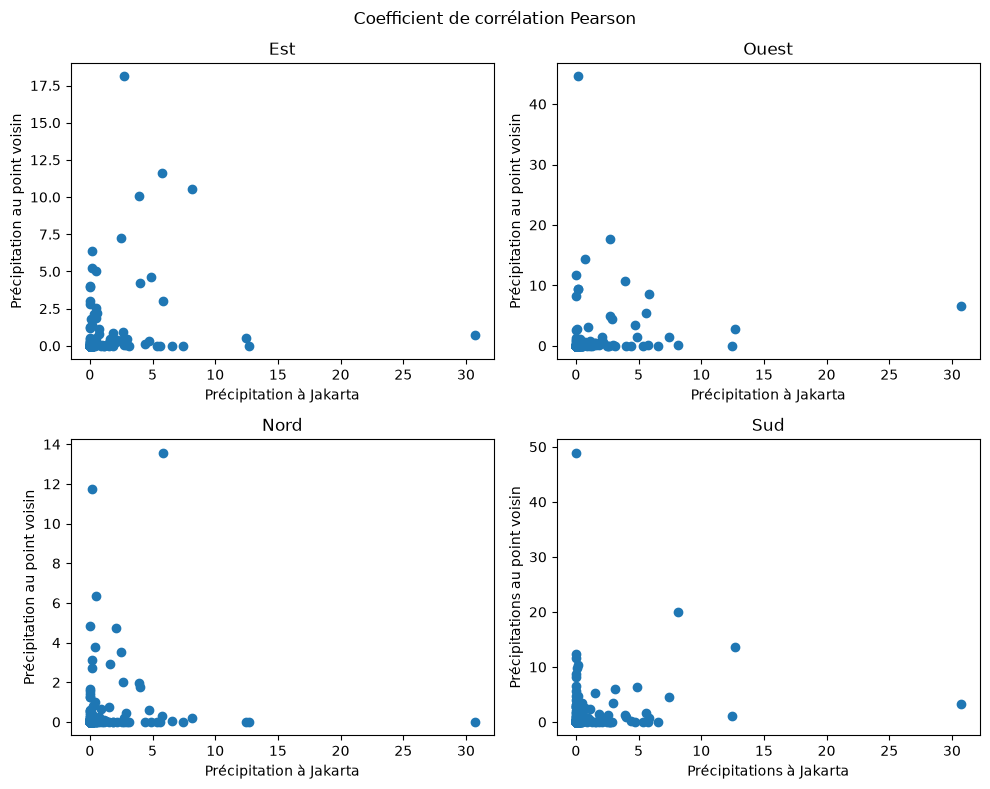

In [23]:
#Graphique de nuages de points pour JAKARTA

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Est
axes[0, 0].scatter(jakarta, jak_est)
axes[0, 0].set_title("Est")
axes[0, 0].set_xlabel("Précipitation à Jakarta")
axes[0, 0].set_ylabel("Précipitation au point voisin")

# Ouest
axes[0, 1].scatter(jakarta, jak_ouest)
axes[0, 1].set_title("Ouest")
axes[0, 1].set_xlabel("Précipitation à Jakarta")
axes[0, 1].set_ylabel("Précipitation au point voisin")

# Nord
axes[1, 0].scatter(jakarta, jak_nord)
axes[1, 0].set_title("Nord")
axes[1, 0].set_xlabel("Précipitation à Jakarta")
axes[1, 0].set_ylabel("Précipitation au point voisin")

# Sud
axes[1, 1].scatter(jakarta, jak_sud)
axes[1, 1].set_title("Sud")
axes[1, 1].set_xlabel("Précipitations à Jakarta")
axes[1, 1].set_ylabel("Précipitations au point voisin")

plt.suptitle("Coefficient de corrélation Pearson")
plt.tight_layout()

plt.savefig("QuestionA3f_Jak.png", bbox_inches="tight")

plt.show()

In [24]:
#Québec

# coefficient de Pearson

corr_estqc = np.corrcoef(quebec.values, qc_est.values)[0, 1]
corr_ouestqc = np.corrcoef(quebec.values, qc_ouest.values)[0, 1]
corr_nordqc = np.corrcoef(quebec.values, qc_nord.values)[0, 1]
corr_sudqc = np.corrcoef(quebec.values, qc_sud.values)[0, 1]

print("Est :", corr_estqc)
print("Ouest :", corr_ouestqc)
print("Nord :", corr_nordqc)
print("Sud :", corr_sudqc)

Est : 0.907300137442869
Ouest : 0.95847679382653
Nord : 0.8714300697376758
Sud : 0.879604039628051


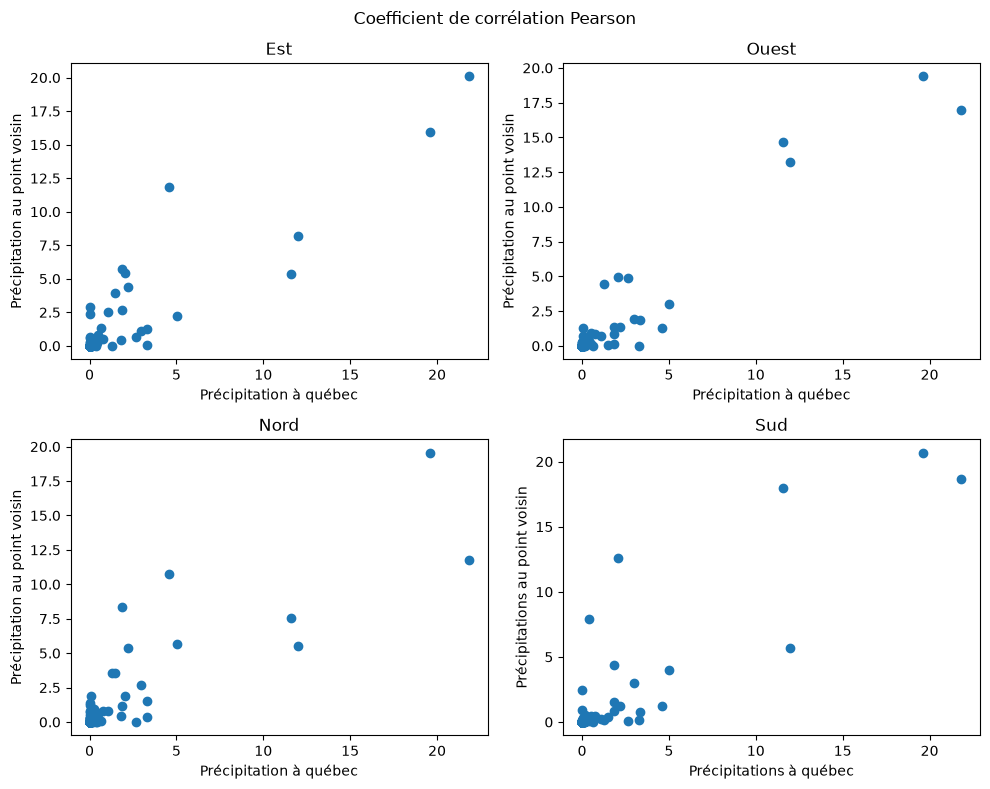

In [25]:
#Graphique de nuages de points pour québec

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Est
axes[0, 0].scatter(quebec, qc_est)
axes[0, 0].set_title("Est")
axes[0, 0].set_xlabel("Précipitation à québec")
axes[0, 0].set_ylabel("Précipitation au point voisin")

# Ouest
axes[0, 1].scatter(quebec, qc_ouest)
axes[0, 1].set_title("Ouest")
axes[0, 1].set_xlabel("Précipitation à québec")
axes[0, 1].set_ylabel("Précipitation au point voisin")

# Nord
axes[1, 0].scatter(quebec, qc_nord)
axes[1, 0].set_title("Nord")
axes[1, 0].set_xlabel("Précipitation à québec")
axes[1, 0].set_ylabel("Précipitation au point voisin")

# Sud
axes[1, 1].scatter(quebec, qc_sud)
axes[1, 1].set_title("Sud")
axes[1, 1].set_xlabel("Précipitations à québec")
axes[1, 1].set_ylabel("Précipitations au point voisin")

plt.suptitle("Coefficient de corrélation Pearson")
plt.tight_layout()

plt.savefig("QuestionA3f_Qc.png", bbox_inches="tight")

plt.show()

In [26]:
#Pacifique

# coefficient de Pearson

corr_estoc = np.corrcoef(ocean.values, oc_est.values)[0, 1]
corr_ouestoc = np.corrcoef(ocean.values, oc_ouest.values)[0, 1]
corr_nordoc = np.corrcoef(ocean.values, oc_nord.values)[0, 1]
corr_sudoc = np.corrcoef(ocean.values, oc_sud.values)[0, 1]

print("Est :", corr_estoc)
print("Ouest :", corr_ouestoc)
print("Nord :", corr_nordoc)
print("Sud :", corr_sudoc)

Est : 0.7718922323193251
Ouest : 0.7568227883452362
Nord : 0.317781882436342
Sud : 0.598681332951888


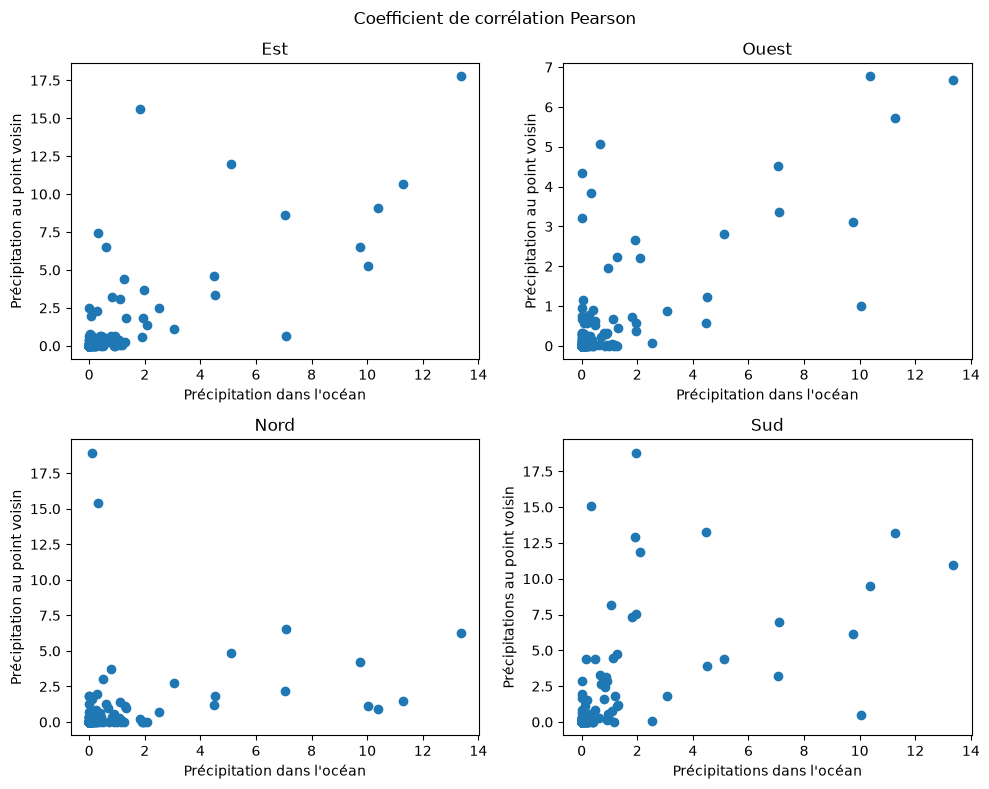

In [27]:
#Graphique de nuages de points pour le pacifique

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Est
axes[0, 0].scatter(ocean, oc_est)
axes[0, 0].set_title("Est")
axes[0, 0].set_xlabel("Précipitation dans l'océan")
axes[0, 0].set_ylabel("Précipitation au point voisin")

# Ouest
axes[0, 1].scatter(ocean, oc_ouest)
axes[0, 1].set_title("Ouest")
axes[0, 1].set_xlabel("Précipitation dans l'océan")
axes[0, 1].set_ylabel("Précipitation au point voisin")

# Nord
axes[1, 0].scatter(ocean, oc_nord)
axes[1, 0].set_title("Nord")
axes[1, 0].set_xlabel("Précipitation dans l'océan")
axes[1, 0].set_ylabel("Précipitation au point voisin")

# Sud
axes[1, 1].scatter(ocean, oc_sud)
axes[1, 1].set_title("Sud")
axes[1, 1].set_xlabel("Précipitations dans l'océan")
axes[1, 1].set_ylabel("Précipitations au point voisin")

plt.suptitle("Coefficient de corrélation Pearson")
plt.tight_layout()

plt.savefig("QuestionA3f_Oc.png", bbox_inches="tight")

plt.show()

In [28]:
#Bologne

# coefficient de Pearson

corr_estbo = np.corrcoef(bologne.values, bo_est.values)[0, 1]
corr_ouestbo = np.corrcoef(bologne.values, bo_ouest.values)[0, 1]
corr_nordbo = np.corrcoef(bologne.values, bo_nord.values)[0, 1]
corr_sudbo = np.corrcoef(bologne.values, bo_sud.values)[0, 1]

print("Est :", corr_estbo)
print("Ouest :", corr_ouestbo)
print("Nord :", corr_nordbo)
print("Sud :", corr_sudbo)

Est : 0.7006015047707642
Ouest : 0.823865615433711
Nord : 0.8476214301313277
Sud : 0.7492261977105023


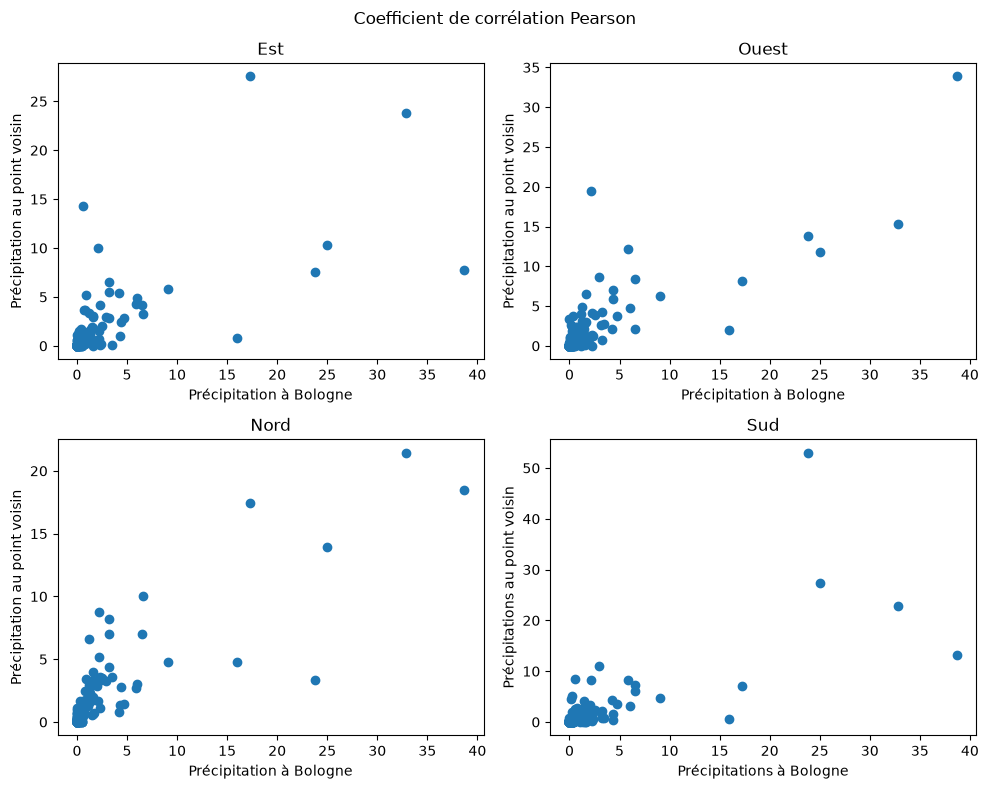

In [29]:
#Graphique de nuages de points pour Bologne

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Est
axes[0, 0].scatter(bologne, bo_est)
axes[0, 0].set_title("Est")
axes[0, 0].set_xlabel("Précipitation à Bologne")
axes[0, 0].set_ylabel("Précipitation au point voisin")

# Ouest
axes[0, 1].scatter(bologne, bo_ouest)
axes[0, 1].set_title("Ouest")
axes[0, 1].set_xlabel("Précipitation à Bologne")
axes[0, 1].set_ylabel("Précipitation au point voisin")

# Nord
axes[1, 0].scatter(bologne, bo_nord)
axes[1, 0].set_title("Nord")
axes[1, 0].set_xlabel("Précipitation à Bologne")
axes[1, 0].set_ylabel("Précipitation au point voisin")

# Sud
axes[1, 1].scatter(bologne, bo_sud)
axes[1, 1].set_title("Sud")
axes[1, 1].set_xlabel("Précipitations à Bologne")
axes[1, 1].set_ylabel("Précipitations au point voisin")

plt.suptitle("Coefficient de corrélation Pearson")
plt.tight_layout()

plt.savefig("QuestionA3f_Bo.png", bbox_inches="tight")

plt.show()

In [32]:
tableau = pd.DataFrame({
    "Jakarta": [
        accum_jakarta.item(),
        freq_jakarta.item(),
        moyenne_precip_jakarta.item(),
        intensite_jakarta.item(),
        (max_consecutif_jak*3),
        max_jakarta.item()
    ],
    "Québec": [
        accum_quebec.item(),
        freq_quebec.item(),
        moyenne_precip_quebec.item(),
        intensite_quebec.item(),
        (max_consecutif_qc*3),
        max_quebec.item()
    ],
    "Pacifique": [
        accum_ocean.item(),
        freq_ocean.item(),
        moyenne_precip_ocean.item(),
        intensite_ocean.item(),
        (max_consecutif_oc*3),
        max_ocean.item()
    ],
    "Bologne": [
        accum_bologne.item(),
        freq_bologne.item(),
        moyenne_precip_bologne.item(),
        intensite_bologne.item(),
        (max_consecutif_bo*3),
        max_bologne.item()
    ]
}, index=[
    "Accumulation totale de précipitations [mm]",
    "Fréquence de précipitation [%]",
    "Taux de précipitation moyen [mm/3h]",
    "Intensité de précipitation moyenne [mm/3h]",
    "Durée maximale des événements de précipitation [h]",
    "Valeur maximale du taux de précipitation [mm/3h]"
])

#faire apparaître le tableau
tableau = tableau.round(2)

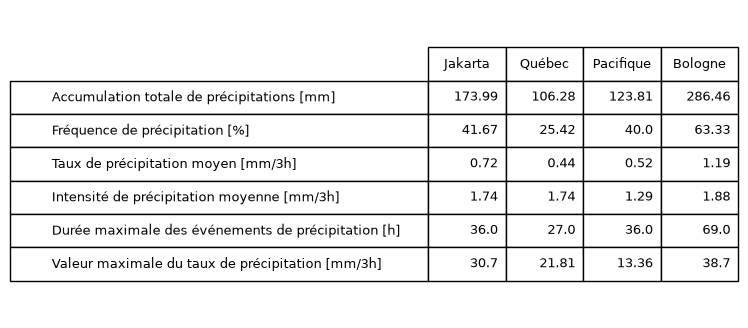

In [33]:
#pour sauvegarder le tableau en png
#aide de l'IA pour comprendre comment sauvergarder un tableau, à l'aide de matplotlib

fig, ax = plt.subplots(figsize=(4, 4))
ax.axis("off")

table = ax.table(
    cellText=tableau.values,
    rowLabels=tableau.index,
    colLabels=tableau.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

plt.savefig("TableauRecap.png", bbox_inches="tight", dpi=300)
plt.show()

In [34]:
#4) Cycle journalier de précipitation

# heure locale de Jakarta : UTC+7
# soit 00h UTC = 7h à Jakarta, 03h = 10h etc... et 21h = 04h le lendemain
#aide de l'IA pour convertir les heures locales et trouver la fonction qui calcule les moyenne d'heures

#on utilise +7 pour convertir le décalage, et le modulo 24 pour les 24h dans la journée - les heures extras retombent dans la moyenne du "lendemain"
heure_locale_jak = (jakarta.time.dt.hour + 7) % 24

# on calcule la moyenne mensuelle pour chaque 3h
jakarta_moy = jakarta.groupby(heure_locale_jak).mean()

print(jakarta_moy)

<xarray.DataArray 'precipitationCal' (hour: 8)> Size: 32B
array([0.39362803, 0.35224354, 0.18933393, 0.6067549 , 1.0020827 ,
       2.3957894 , 0.7655106 , 0.09438895], dtype=float32)
Coordinates:
  * hour     (hour) int64 64B 1 4 7 10 13 16 19 22
    lon      float32 4B 106.8
    lat      float32 4B -6.15
Attributes:
    units:    mm/3h


In [35]:
# heure locale de Québec : UTC-4 pendant l'hiver
# soit 00h UTC = 20h à Québec(la veille), 03h = 23h etc.


#on utilise -4 pour convertir le décalage, et le modulo 24 pour les 24h dans la journée - les heures en moins retombent dans la moyenne de la veille
heure_locale_qc = (quebec.time.dt.hour -4) % 24

# on calcule la moyenne mensuelle pour chaque 3h
quebec_moy = quebec.groupby(heure_locale_qc).mean()


print(quebec_moy)

<xarray.DataArray 'precipitationCal' (hour: 8)> Size: 32B
array([0.6795022 , 0.6405376 , 0.09096222, 0.11380596, 0.07176299,
       0.11032283, 1.0044571 , 0.8312464 ], dtype=float32)
Coordinates:
  * hour     (hour) int64 64B 2 5 8 11 14 17 20 23
    lon      float32 4B -71.15
    lat      float32 4B 46.85
Attributes:
    units:    mm/3h


In [36]:
# heure locale pacifique : UTC+7
# soit 00h UTC = 7h , 03h = 10h etc... et 21h = 04h le lendemain

#on utilise +1 pour convertir le décalage, et le modulo 24 pour les 24h dans la journée - les heures extras retombent dans la moyenne du "lendemain"
heure_locale_oc = (ocean.time.dt.hour + 7) % 24

# on calcule la moyenne mensuelle pour chaque 3h
ocean_moy = ocean.groupby(heure_locale_oc).mean()

print(ocean_moy)

<xarray.DataArray 'precipitationCal' (hour: 8)> Size: 32B
array([0.50082743, 0.581297  , 0.27063626, 0.40074623, 0.82481784,
       0.55265445, 0.6925331 , 0.3036407 ], dtype=float32)
Coordinates:
  * hour     (hour) int64 64B 1 4 7 10 13 16 19 22
    lon      float32 4B 106.1
    lat      float32 4B 7.05
Attributes:
    units:    mm/3h


In [37]:
# heure locale à Bologne : UTC+1 pendant l'hiver 
# soit 00h UTC = 1h , 03h = 4h etc...

#on utilise +7 pour convertir le décalage, et le modulo 24 pour les 24h dans la journée - les heures extras retombent dans la moyenne du "lendemain"
heure_locale_bo = (bologne.time.dt.hour + 1) % 24

# on calcule la moyenne mensuelle pour chaque 3h
bologne_moy = bologne.groupby(heure_locale_bo).mean()

print(bologne_moy)

<xarray.DataArray 'precipitationCal' (hour: 8)> Size: 32B
array([1.8773139 , 0.611024  , 0.6511644 , 0.5322214 , 0.4238282 ,
       0.85311496, 2.7735085 , 1.826584  ], dtype=float32)
Coordinates:
  * hour     (hour) int64 64B 1 4 7 10 13 16 19 22
    lon      float32 4B 11.35
    lat      float32 4B 44.55
Attributes:
    units:    mm/3h


In [38]:
#connaître la moyenne mensuelle la plus haute pour trouver la limite d'axe y

y_max = max(
    jakarta_moy.max().item(),
    quebec_moy.max().item(),
    ocean_moy.max().item(),
    bologne_moy.max().item()
)
print(y_max)

2.7735085487365723


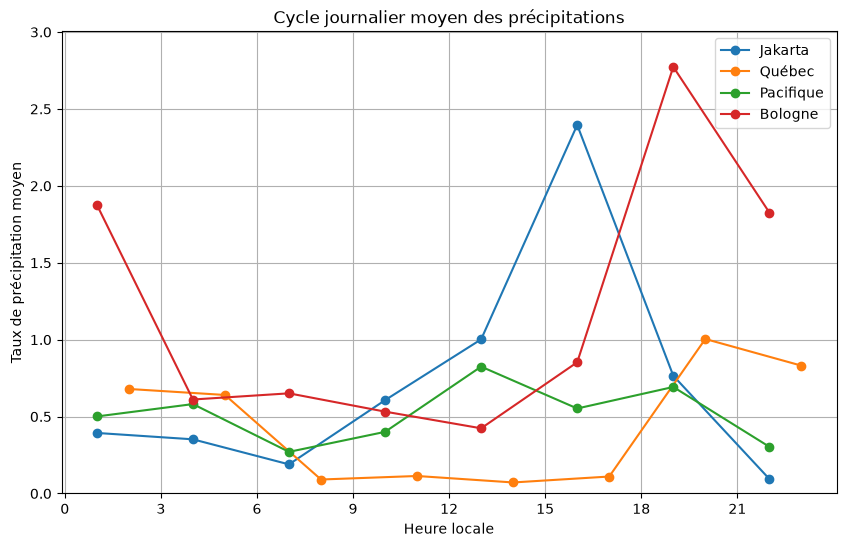

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(jakarta_moy.hour, jakarta_moy, marker="o", label="Jakarta")
plt.plot(quebec_moy.hour, quebec_moy, marker="o", label="Québec")
plt.plot(ocean_moy.hour, ocean_moy, marker="o", label="Pacifique")
plt.plot(bologne_moy.hour, bologne_moy, marker="o", label="Bologne")

plt.xlabel("Heure locale")
plt.ylabel("Taux de précipitation moyen")
plt.title("Cycle journalier moyen des précipitations")

plt.ylim(0, y_max+0.23) #ajout d'une marge pour l'esthétique du tableau

#axe x de 0 à 24 par pas de 3h
plt.xticks(range(0, 24, 3))  # heure de 0 à 24 par pas de 3



plt.legend()
plt.grid()

plt.savefig("QuestionA4.png", bbox_inches="tight")

plt.show()

Analyse des champs spatiaux

In [40]:
#sélection des données de toutes les latitudes et longitudes au moment du 1er novembre à 12UTC 

precip_12 = ds.precipitationCal.sel(
    time="2019-11-01T12:00:00"
)

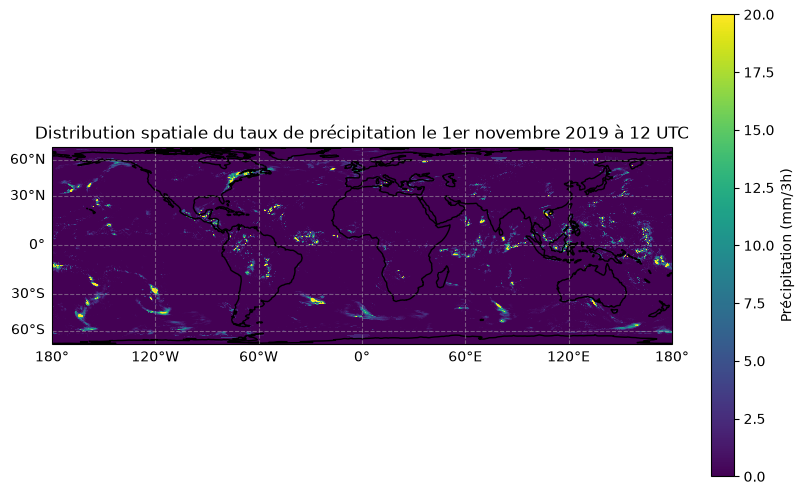

In [41]:
#1) Distribution sptatiale du taux de précipitation pour le 1er novembre à 12UTC

import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(10, 6))

#projection lambert Cylindrical
ax = plt.axes(projection=ccrs.LambertCylindrical())

#pcolormesh fait la carte colorée à partir de la grille de données
im = ax.pcolormesh(
    ds.lon,
    ds.lat,
    ds.precipitationCal.isel(time=0),
    transform=ccrs.PlateCarree(),  #conversion du système de coordonnées lon/lat à la projection Lambert Cylindrical
    vmin=0,  #échelle des couleurs de 0 à 20mm/3h. Les valeurs supérieures à 20mm/3h sont normalisées à 20mm/3h
    vmax=20
)

#ajoute les délimitations des côtes et continents
ax.coastlines()

#ajoute le quadrillage des longitudes et latitudes
gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    alpha=0.5
)

#pour avoir des coordonnées seulement sur les axes x et y respectivement.
gl.top_labels = False
gl.right_labels = False

plt.title("Distribution spatiale du taux de précipitation le 1er novembre 2019 à 12 UTC")
plt.colorbar(im, label="Précipitation (mm/3h)")

plt.savefig("QuestionB1.png", bbox_inches="tight")


plt.show()

In [42]:
#2) Nombre de valeur pour différente intensité 

#trouver le taux de précipitation max à 12UTC
max_precip = ds.precipitationCal.sel(time="2019-11-01T12:00:00").max()

print("Le taux de précipitation maximum est", f"{max_precip:.2f}", "mm/3h")

Le taux de précipitation maximum est 180.43 mm/3h


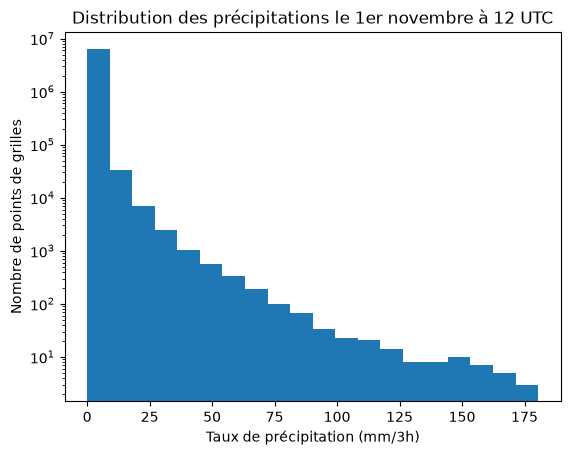

In [43]:
#On peut ainsi séparer 20 classes d'intensité d'intervalle de 0 à 9 mm/3h - (180/20)


plt.hist(
    precip_12.values.flatten(),  #aide de l'IA pour tracer l'histogramme
    bins=20,   #20 classes d'intensités
    range=(0, max_precip.item()) #qui se rendent de 0 au max
)
plt.yscale("log")  #echelle logarithmique

plt.xlabel("Taux de précipitation (mm/3h)")
plt.ylabel("Nombre de points de grilles")
plt.title("Distribution des précipitations le 1er novembre à 12 UTC")

plt.savefig("QuestionB2.png", bbox_inches="tight")
plt.show()

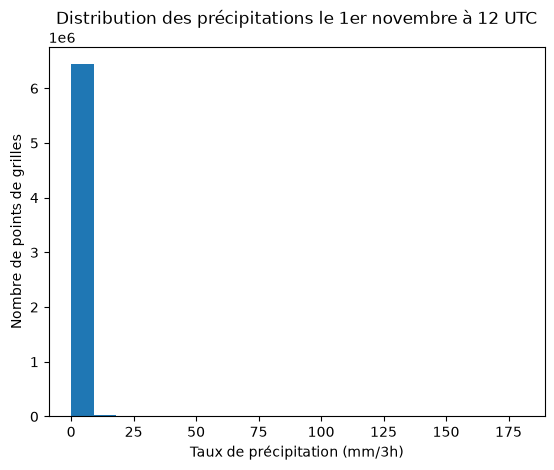

In [44]:
#Copie du code sans l'échelle logarithmique

plt.hist(
    precip_12.values.flatten(),  #aide de l'IA pour tracer l'histogramme
    bins=20,   #20 classes d'intensités
    range=(0, max_precip.item()) #qui se rendent de 0 au max
)
#plt.yscale("log")  # on retire l'echelle logarithmique

plt.xlabel("Taux de précipitation (mm/3h)")
plt.ylabel("Nombre de points de grilles")
plt.title("Distribution des précipitations le 1er novembre à 12 UTC")

plt.savefig("QuestionB2b.png", bbox_inches="tight")
plt.show()

In [45]:
print(max_precip)
print(max_precip.shape)

<xarray.DataArray 'precipitationCal' ()> Size: 4B
array(180.42758, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2019-11-01T12:00:00
Attributes:
    units:    mm/3h
()


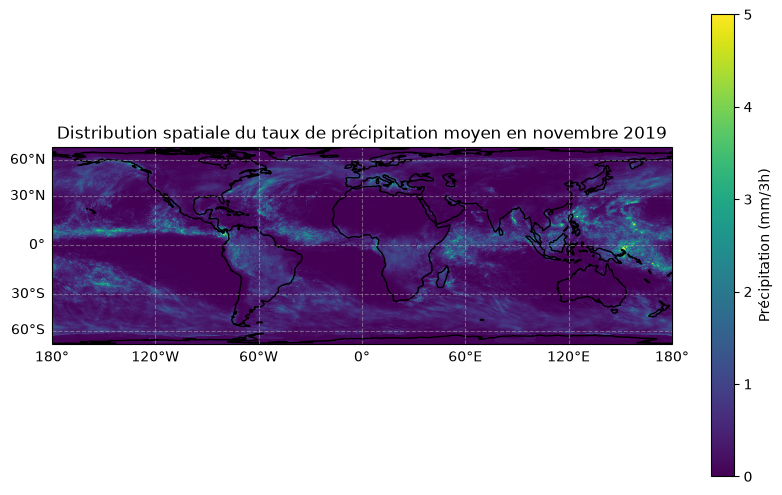

In [46]:
#3) Distribution spatiale du taux de précipitation moyen en novembre 2019

plt.figure(figsize=(10, 6))

#projection lambert Cylindrical
ax = plt.axes(projection=ccrs.LambertCylindrical())

#pcolormesh fait la carte colorée à partir de la grille de données
im = ax.pcolormesh(
    ds.lon,
    ds.lat,
    ds.precipitationCal.mean(dim="time"), #moyenne de toutes les valeurs selon la dimension du temps. conserve lat et lon 
    transform=ccrs.PlateCarree(),  #conversion du système de coordonnées lon/lat à la projection Lambert Cylindrical
    vmin=0,  #échelle des couleurs de 0 à 5mm/3h. Les valeurs supérieures à 5mm/3h sont normalisées à 5mm/3h
    vmax=5
)

#ajoute les délimitations des côtes et continents
ax.coastlines()

#ajoute le quadrillage des longitudes et latitudes
gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    alpha=0.5
)

#pour avoir des coordonnées seulement sur les axes x et y respectivement.
gl.top_labels = False
gl.right_labels = False

plt.title("Distribution spatiale du taux de précipitation moyen en novembre 2019")
plt.colorbar(im, label="Précipitation (mm/3h)")

plt.savefig("QuestionB3.png", bbox_inches="tight")

plt.show()

In [47]:
#4) Taux de précipitation moyenné sur tout le mois de novembre

#trouver le taux de précipitation moyen maximum de novembre
moy_max_precip = ds.precipitationCal.mean(dim="time").max()

print("Le taux de précipitation moyen maximum de novembre 2019 est", f"{moy_max_precip:.2f}", "mm/3h")

Le taux de précipitation moyen maximum de novembre 2019 est 5.97 mm/3h


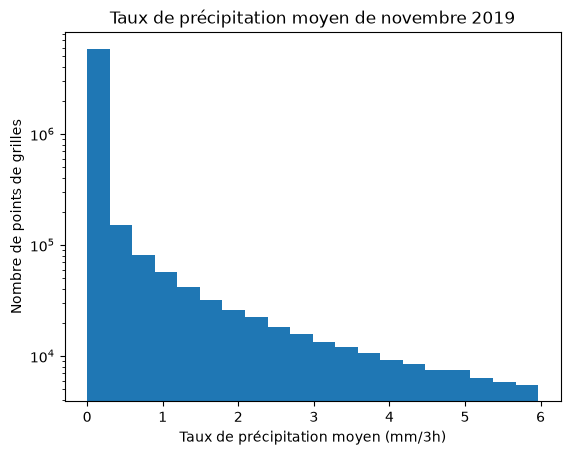

In [48]:
#On peut ainsi séparer 20 classes d'intensité d'intervalle de 0 à 9 mm/3h - (180/20)

plt.hist(
    precip_12.values.flatten(), 
    bins=20,   #20 classes d'intensités
    range=(0, moy_max_precip.item()) #qui se rendent de 0 au max
)
plt.yscale("log")  #echelle logarithmique

plt.xlabel("Taux de précipitation moyen (mm/3h)")
plt.ylabel("Nombre de points de grilles")
plt.title("Taux de précipitation moyen de novembre 2019")

plt.savefig("QuestionB4.png", bbox_inches="tight")

plt.show()

In [52]:
#5) avant de tracer, on sort les valeurs max dans notre intervalle de latitudes et longitudes, pour avoir une échelle de couleur plus représentative

moyenne_nov = ds.precipitationCal.mean(dim="time")

zone = moyenne_nov.sel(
    lat=slice(44.5, 46.5),
    lon=slice(-74.58, -72.58)
    
)

print("Maximum :", zone.max().item())

Maximum : 0.39312440156936646


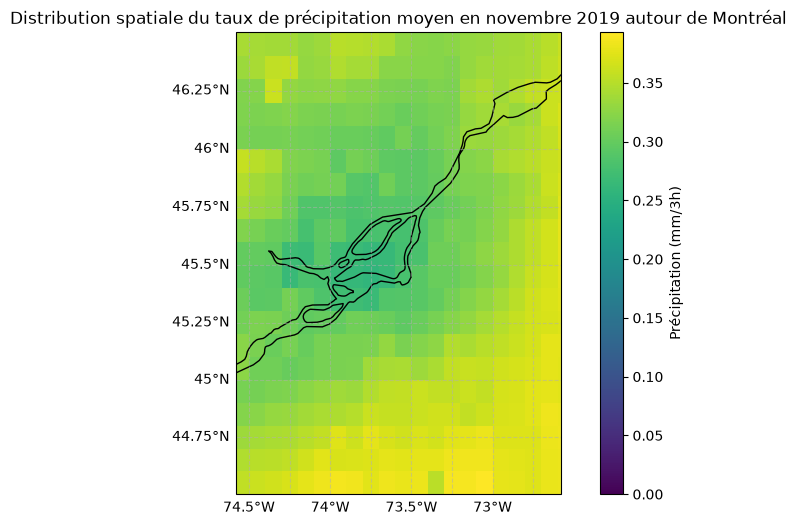

In [53]:
#5) Distribution spatiale du taux de précipitation moyen en nov

plt.figure(figsize=(10, 6))

#projection Mercator
ax = plt.axes(projection=ccrs.Mercator())

#pcolormesh fait la carte colorée à partir de la grille de données
im = ax.pcolormesh(
    ds.lon,
    ds.lat,
    ds.precipitationCal.mean(dim="time"), #moyenne de toutes les valeurs selon la dimension du temps. conserve lat et lon 
    transform=ccrs.PlateCarree(),  #conversion du système de coordonnées lon/lat à la projection Mercator
    vmin = 0,
    vmax = zone.max().item()
)

#j'ajoute des limites de longitudes [x1, x2, y1, y2] et latitudes voulues, autour de Montréal 
#Montréal est enviorn située à [73.58 O ; 45.50 N]
ax.set_extent([-72.58, -74.58, 44.5, 46.5], crs=ccrs.PlateCarree()) #outil trouvé avce IA

#ajoute les délimitations des côtes et continents
ax.coastlines()

#ajoute le quadrillage des longitudes et latitudes
gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    alpha=0.5
)

#pour avoir des coordonnées seulement sur les axes x et y respectivement.
gl.top_labels = False
gl.right_labels = False

plt.title("Distribution spatiale du taux de précipitation moyen en novembre 2019 autour de Montréal")
plt.colorbar(im, label="Précipitation (mm/3h)")

plt.savefig("QuestionB5.png", bbox_inches="tight")

plt.show()

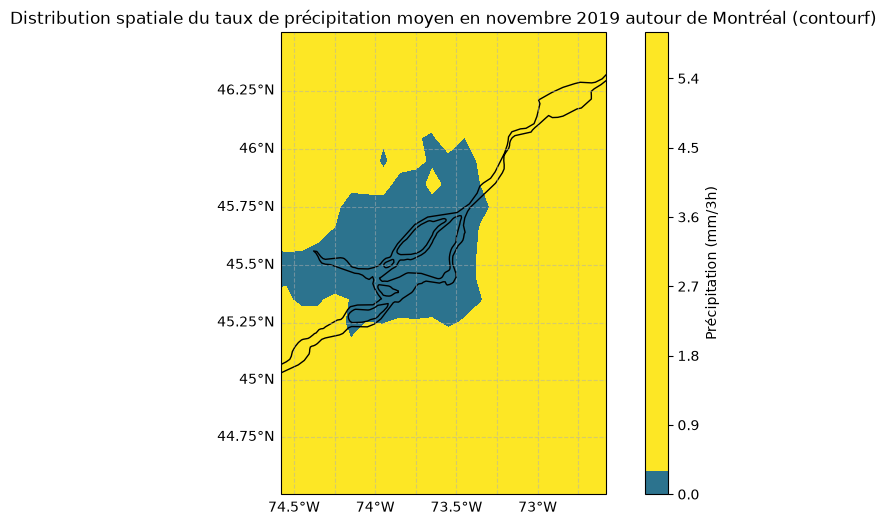

In [54]:
#6) Distribution spatiale du taux de précipitation moyen en novembre, avec contourf 

plt.figure(figsize=(10, 6))

# projection Mercator
ax = plt.axes(projection=ccrs.Mercator())

# contourf fait des zones de couleur à partir de la grille de données
im = ax.contourf(
    ds.lon,
    ds.lat,
    ds.precipitationCal.mean(dim="time"), # moyenne sur le temps, conserve lat et lon
    transform=ccrs.PlateCarree(), # coordonnées des données en lon/lat
    levels=20,
    vmin = 0,
    vmax = zone.max().item()
)

# limites de longitudes et latitudes autour de Montréal
# Montréal est environ située à [-73.58, 45.50]
ax.set_extent(
    [-74.58, -72.58, 44.5, 46.5],
    crs=ccrs.PlateCarree()
)

# délimitations des côtes et continents
ax.coastlines()

# quadrillage des longitudes et latitudes
gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    alpha=0.5
)

# coordonnées seulement sur les axes x et y
gl.top_labels = False
gl.right_labels = False

plt.title("Distribution spatiale du taux de précipitation moyen en novembre 2019 autour de Montréal (contourf)")
plt.colorbar(im, label="Précipitation (mm/3h)")


plt.savefig("QuestionB6.png", bbox_inches="tight")

plt.show()

Figure bonus

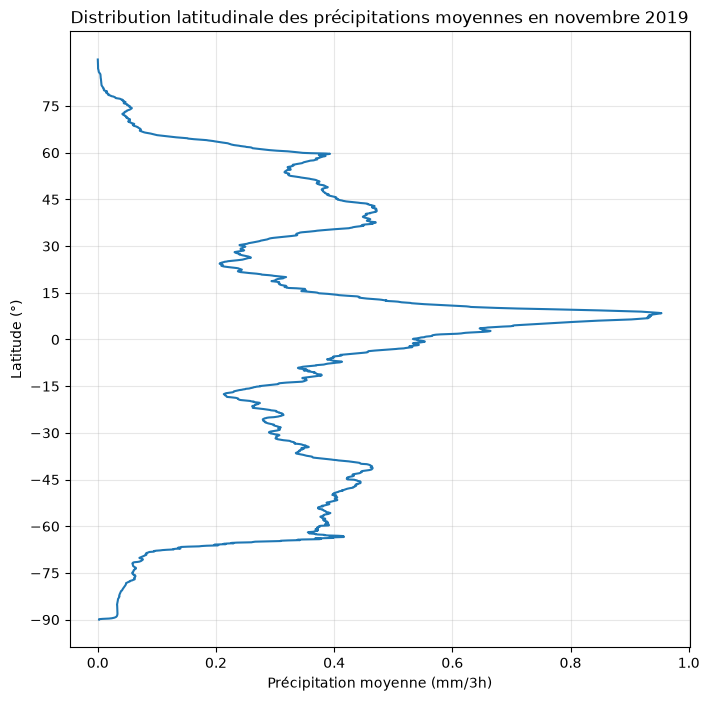

In [57]:
#L'objectif est de faire une moyenne latitudinale et mensuelle des précipitations, afin de repérer leur distribution

#moyenne temporelle et longitunale
precip_moy_lat = ds.precipitationCal.mean(dim=["time","lon"])

#pour que la représentation soit plus parlante, on garde la latitude en axe y et en x le taux de précipitations
plt.figure(figsize=(8, 8))

plt.plot(precip_moy_lat, ds.lat)

plt.xlabel("Précipitation moyenne (mm/3h)")
plt.ylabel("Latitude (°)")
plt.title("Distribution latitudinale des précipitations moyennes en novembre 2019")

plt.grid(alpha=0.3)

#axe y de -90 à 90 par pas de 15°
plt.yticks(range(-90, 90, 15))  

plt.savefig("FigureBonus.png", bbox_inches="tight")
plt.show()